# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')#completa el código
usage = pd.read_csv('/datasets/usage.csv')#completa el código

In [3]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:

# cantidad de nulos para users
print("Cantidad de valores nulos en users:")
print(users.isna().sum())

print("\nProporción de valores nulos en users:")
print(users.isna().mean())


Cantidad de valores nulos en users:
user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

Proporción de valores nulos en users:
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:

# cantidad de nulos para usage
print("\nCantidad de valores nulos en usage:")
print(usage.isna().sum())

print("\nProporción de valores nulos en usage:")
print(usage.isna().mean())




Cantidad de valores nulos en usage:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

Proporción de valores nulos en usage:
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

**Diagnóstico de valores nulos**

#Dataset plans: No presenta valores nulos, por lo que no requiere limpieza.
Dataset users: 

•	city (11.73%): Se recomienda investigar la causa e imputar o conservar los nulos según su impacto en el análisis.


•	churn_date (88.35%): Se recomienda conservar los nulos, ya que probablemente representan clientes que aún no han cancelado el servicio.
Dataset usage:

•	date (0.13%): Se recomienda imputar o eliminar estos pocos registros debido a su baja proporción.

•	duration (55.19%): Se recomienda investigar si los nulos corresponden a registros de mensajes antes de imputar.


•	length (44.74%): Se recomienda verificar si los nulos corresponden a registros de llamadas antes de realizar cualquier tratamiento.

**Conclusión:** Los valores nulos deben analizarse según el significado de cada variable antes de decidir si imputarlos, eliminarlos o conservarlos.

  

### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:




# explorar columnas numéricas de users
users.describe()





,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- La columna `user_id`: Contiene identificadores dentro del rango esperado y no se observan valores inválidos.
- La columna `age`: Se detecta un valor mínimo de -999, que corresponde a un sentinel porque una edad negativa no es válida y debe revisarse.

In [13]:

# explorar columnas numéricas de usage
usage.describe()


,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000



- Las columnas `id` y `user_id`: Contienen identificadores con rangos coherentes y no presentan valores inválidos.
- Las columnas: duration y length: No presentan valores negativos; sin embargo, existen registros con valor 0, por lo que conviene verificar si representan datos válidos o un posible sentinel según el contexto del negocio.


In [14]:
# explorar columnas categóricas de users

columnas_user = ['city', 'plan']

for columna in columnas_user:
    print(f"\nValores únicos de {columna}:")
    print(users[columna].unique())




Valores únicos de city:
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

Valores únicos de plan:
['Basico' 'Premium']


- La columna `city` : Contiene ciudades válidas, pero también presenta el valor "?" y valores nulos (NaN), los cuales indican información faltante o un posible sentinel.
- La columna `plan`: Solo contiene las categorías esperadas (Basico y Premium), sin valores inválidos.

In [15]:


# explorar columna categórica de usage
usage['type'] .unique()# completa el código



array(['call', 'text'], dtype=object)

- La columna `type` : Solo contiene las categorías esperadas (call y text), por lo que no se identifican valores inválidos o sentinels.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 


- **Diagnóstico**

- users['age']: Se observa un valor mínimo de -999, el cual es imposible para una edad y corresponde a un valor centinela o error de captura.
  
Acción recomendada : Reemplazar -999 por valores nulos (NaN) para tratarlos posteriormente mediante imputación o eliminación, según el análisis.

- users['user_id'] y usage['id']: Los identificadores presentan rangos consistentes y no muestran valores anómalos. 

Acción recomendada: No se requiere ninguna acción de limpieza. 

- usage['duration']: El mínimo es 0 y el máximo 120. La presencia de llamadas con duración 0 puede corresponder a llamadas no contestadas o canceladas. 

Acción recomendada: Verificar la documentación del conjunto de datos antes de eliminar estos registros; si representan llamadas fallidas, pueden conservarse. 

- usage['length']: Presenta valores entre 0 y 1490 caracteres. Los mensajes con longitud 0 podrían representar mensajes vacíos o errores de registro. 

Acción recomendada: Validar el significado de estos valores con la documentación y decidir si deben mantenerse o excluirse. 

- users['city']: Se observan valores válidos, además de ? y valores nulos (NaN), que indican información faltante o no registrada. 

Acción recomendada: Reemplazar ? por NaN y posteriormente imputar o mantener los nulos según el objetivo del análisis. 

- users['plan']: Solo contiene las categorías Basico y Premium, sin valores inesperados. 

Acción recomendada: No requiere limpieza. 

- usage['type']: Solo presenta las categorías call y text, lo que indica consistencia en la variable. 

Acción recomendada: No requiere limpieza.

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
  
  users['age']: Se encontró el valor -999, el cual es un valor centinela y no representa una edad válida.
  
 users['city']: Se encontró el valor ?, que indica un dato desconocido o faltante y también puede considerarse un valor centinela. 
 
- ¿Qué acción tomarías?
  
  En users['age'], reemplazaría -999 por NaN para tratarlo posteriormente mediante imputación o eliminación, según el análisis.
  
   En users['city'], reemplazaría ? por NaN y posteriormente decidiría si imputar el valor o mantenerlo como dato faltante, dependiendo del objetivo del análisis.


### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [16]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')# completa el código

In [17]:

# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')# completa el código


In [18]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.value_counts().sort_index()


2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64

En `reg_date`: Se observan registros de los años 2022, 2023 y 2024, que son válidos, pero también 40 registros del año 2026, el cual está fuera del rango esperado (hasta 2024) y sugiere un posible error de captura que debe revisarse o corregirse.

In [19]:


# Revisar los años presentes en `date` de usage
usage['date'].dt.year.value_counts().sort_index()




2024.0    39950
Name: date, dtype: int64

En `date`:: Todos los registros corresponden al año 2024, por lo que las fechas se encuentran dentro del rango esperado y no se identifican años inválidos. Basaremos el análisis en estas fechas.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Diagnóstico**

-users['reg_date']: Se observan registros correspondientes a 2022, 2023, 2024 y 2026. Dado que el conjunto de datos de uso solo contiene información de 2024, la presencia de registros de 2026 resulta inconsistente y podría deberse a errores de captura o fechas incorrectas. En cambio, las fechas de 2022 y 2023 pueden ser válidas si representan usuarios que se registraron antes del período analizado. 

•	Acción recomendada: Investigar los registros de 2026 y corregirlos o eliminarlos si se confirma que son errores. Mantener los registros de 2022 y 2023, ya que son coherentes con usuarios registrados antes de 2024. 

-usage['date']: Todos los registros pertenecen al año 2024, lo que indica que las fechas son consistentes con el período de análisis. 

•	Acción recomendada: No se requiere ninguna acción de limpieza sobre esta columna.



**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos): 
  Sí. En users['reg_date'] aparecen 40 registros del año 2026, un año futuro respecto al período de análisis.
  No se encontraron años fuera de rango en usage['date'].
  
- ¿Qué harías con ellas?:
  Revisar los registros con fecha 2026 para confirmar si se trata de un error de captura (por ejemplo, si debería ser 2024 o 2023). Si no es posible corregirlos con información adicional, marcarlos como valores faltantes (NaT) o excluirlos del análisis para evitar sesgos.
  No se requiere ninguna acción sobre usage['date'], ya que todas las fechas son válidas.

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [20]:
# Reemplazar -999 por la mediana de age
age_mediana = users.loc[users['age'] != -999, 'age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace('?', pd.NA)


# Verificar cambios
users['city'].value_counts(dropna=False)

Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64

In [22]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT


# Verificar cambios
users['reg_date'].dt.year.value_counts(dropna=False).sort_index()


2022.0    1314
2023.0    1316
2024.0    1330
NaN         40
Name: reg_date, dtype: int64

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [23]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().sum())


type
call        0
text    22076
Name: duration, dtype: int64

In [24]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().sum())


type
call    17896
text        0
Name: length, dtype: int64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

**Diagnóstico**

•	Los valores nulos de duration aparecen únicamente cuando type = 'text', ya que los mensajes no tienen duración.

•	Los valores nulos de length aparecen únicamente cuando type = 'call', ya que las llamadas no tienen longitud de mensaje.

Los valores nulos dependen directamente de la variable type, por lo que no representan errores sino la ausencia natural de información para ese tipo de registro. Se decide conservarlos como nulos, ya que reemplazarlos podría introducir información incorrecta y afectar el análisis.

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [25]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = (
    usage.groupby("user_id")
         .agg({
             "is_text": "sum",
             "is_call": "sum",
             "duration": "sum"
         })
         .reset_index())

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [26]:
# Renombrar columnas

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [27]:

# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(
    usage_agg,
    on="user_id",
    how="left"
)
user_profile.head(5)


,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,is_text,is_call,duration
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [28]:
# Resumen estadístico de las columnas numéricas
user_profile[
    ["age", "is_text", "is_call", "duration"]
].describe()


,age,is_text,is_call,duration
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


In [29]:
# Distribución porcentual del tipo de plan
(user_profile["plan"]
 .value_counts(normalize=True)
 .mul(100)
 .round(2))


Basico     64.88
Premium    35.12
Name: plan, dtype: float64

---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

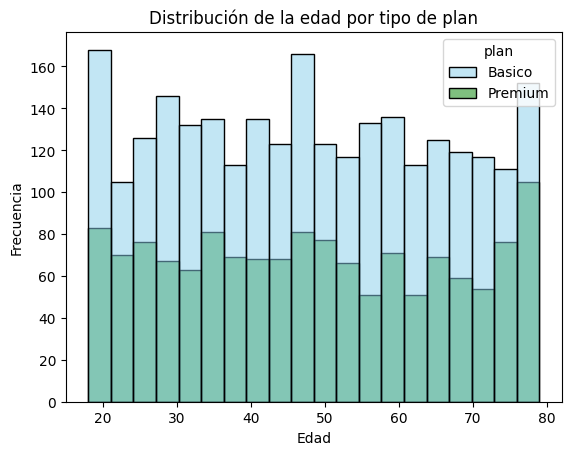

In [30]:
# Histograma para visualizar la edad (age)
sns.histplot(
    data=user_profile,
    x="age",
    hue="plan",
    palette=["skyblue", "green"],
    bins=20
)

plt.title("Distribución de la edad por tipo de plan")
plt.xlabel("Edad")
plt.ylabel("Frecuencia")
plt.show()

💡Insights: 
- La distribución de edades es similar entre ambos planes. No se observa una concentración marcada de un plan en un rango de edad específico. La distribución es aproximadamente simétrica.

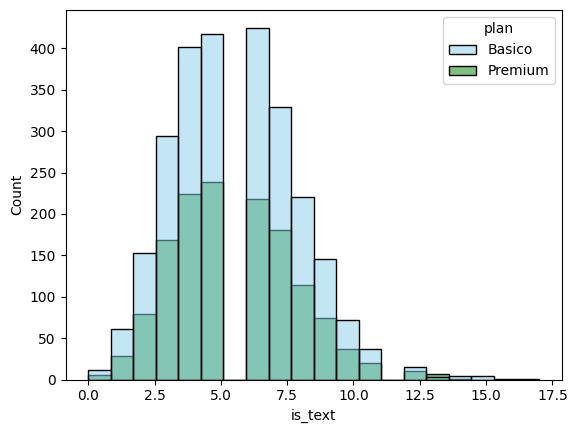

In [31]:
# Histograma para visualizar la cant_mensajes
sns.histplot(
    data=user_profile,
    x="is_text",
    hue="plan",
    palette=["skyblue", "green"],
    bins=20
)

plt.show()


💡Insights: 
- No se observa un patrón claro entre el plan Básico y Premium en la cantidad de mensajes enviados. La mayoría de los usuarios registra entre 3 y 8 mensajes, y la distribución está sesgada a la derecha debido a unos pocos usuarios con valores altos.

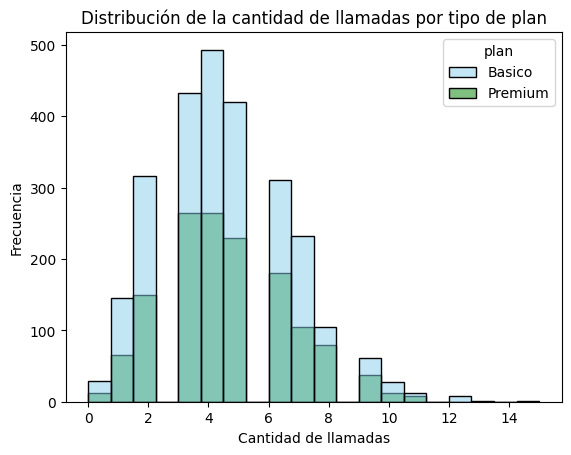

In [32]:
# Histograma para visualizar la cant_llamadas
sns.histplot(
    data=user_profile,
    x="is_call",
    hue="plan",
    palette=["skyblue", "green"],
    bins=20
)

plt.title("Distribución de la cantidad de llamadas por tipo de plan")
plt.xlabel("Cantidad de llamadas")
plt.ylabel("Frecuencia")
plt.show()


💡Insights: 
- Distribución: No se observa un patrón claro entre el tipo de plan y la cantidad de llamadas realizadas. La mayoría de los usuarios efectúa entre 3 y 7 llamadas, y la distribución presenta un sesgo a la derecha debido a algunos usuarios con un número elevado de llamadas.

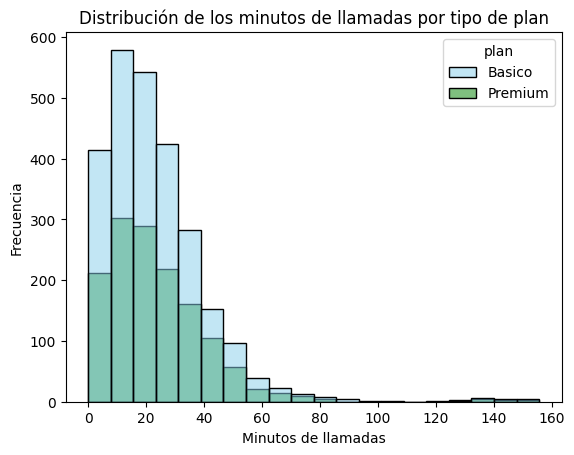

In [33]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(
    data=user_profile,
    x="duration",
    hue="plan",
    palette=["skyblue", "green"],
    bins=20
)

plt.title("Distribución de los minutos de llamadas por tipo de plan")
plt.xlabel("Minutos de llamadas")
plt.ylabel("Frecuencia")
plt.show()


💡Insights: 
- No se observa un patrón claro entre el tipo de plan y los minutos de llamadas. La mayoría de los usuarios acumula entre 10 y 30 minutos de llamadas, mientras que pocos usuarios presentan consumos muy altos, lo que genera una distribución sesgada a la derecha.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

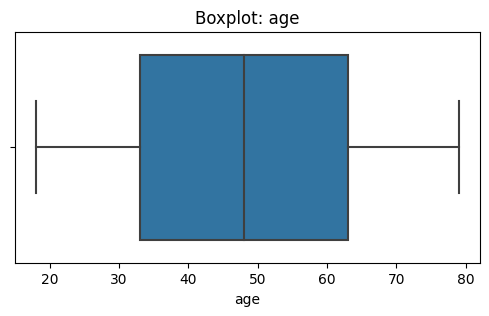

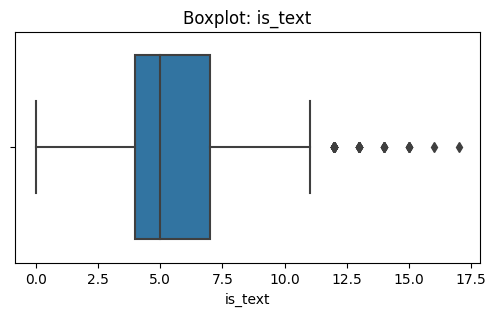

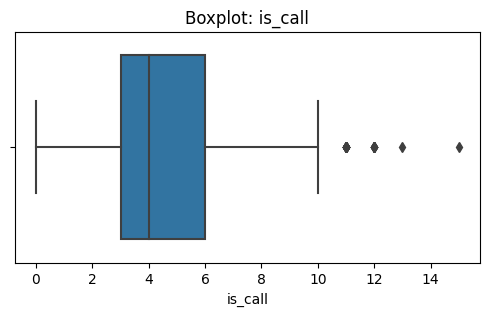

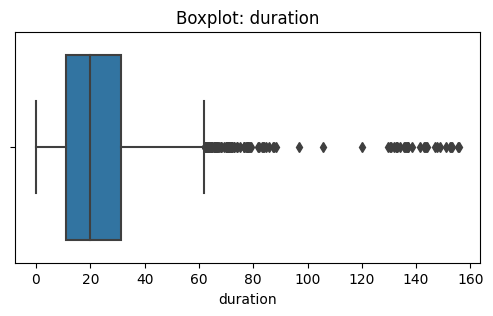

In [276]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'is_text', 'is_call', 'duration']

for col in columnas_numericas:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=user_profile[col])
    plt.title(f'Boxplot: {col}')
    plt.show() 

💡Insights: 
- **Age:**
  La distribución es amplia, con edades desde 20 hasta 80. El rango intercuartílico (IQR) está entre 30 y 65, y la mediana cerca de 50.
  
No se observan puntos fuera de los bigotes y no hay outliers significativos.

- **cant_mensajes:**
  La mayoría de usuarios envían entre 4 y 7 mensajes. Mediana alrededor de 5.
  Sí hay outliers claros entre 12 y 17 usuarios que envían MUCHOS más mensajes que el promedio.
  
- **cant_llamadas:**
  La mayoría de usuarios realizan entre 2 y 7 llamadas. Mediana alrededor de 4.
  En cuanto a Outliers: Hay varios puntos entre 10 y 14 usuarios que hacen muchas más llamadas que el resto.
 
- **cant_minutos_llamada:**
  La mayoría de usuarios acumulan entre 10 y 35 minutos de llamada. Mediana cerca de 20.
  En cuanto a Outliers: Muchos valores extremos entre 60 y 150 usuarios con tiempos de llamada muy elevados.

In [34]:
# Calcular límites con el método IQR
columnas_limites = ['age', 'is_text', 'is_call', 'duration']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    print(f"\nVariable: {col}")
    print(f"Q1: {Q1}")
    print(f"Q3: {Q3}")
    print(f"IQR: {IQR}")
    print(f"Límite inferior: {limite_inferior}")
    print(f"Límite superior: {limite_superior}")




Variable: age
Q1: 33.0
Q3: 63.0
IQR: 30.0
Límite inferior: -12.0
Límite superior: 108.0

Variable: is_text
Q1: 4.0
Q3: 7.0
IQR: 3.0
Límite inferior: -0.5
Límite superior: 11.5

Variable: is_call
Q1: 3.0
Q3: 6.0
IQR: 3.0
Límite inferior: -1.5
Límite superior: 10.5

Variable: duration
Q1: 11.12
Q3: 31.415
IQR: 20.295
Límite inferior: -19.322500000000005
Límite superior: 61.8575


In [35]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
columnas_limites = ['age', 'is_text', 'is_call', 'duration']
user_profile[columnas_limites].describe()

,age,is_text,is_call,duration
count,4000.000000,3999.000000,3999.000000,3999.000000
mean,48.136000,5.524381,4.478120,23.317054
std,17.689919,2.358416,2.144238,18.168095
min,18.000000,0.000000,0.000000,0.000000
25%,33.000000,4.000000,3.000000,11.120000
50%,48.000000,5.000000,4.000000,19.780000
75%,63.000000,7.000000,6.000000,31.415000
max,79.000000,17.000000,15.000000,155.690000


💡Insights: 
- **cant_mensajes: mantener o no outliers, porqué?**
  Se identifican outliers superiores, ya que el valor máximo (17) supera el límite superior (11.5). Se recomienda mantenerlos, porque representan usuarios con una actividad de mensajería más intensa y no evidencian errores de registro.
  
- **cant_llamadas: mantener o no outliers, porqué?**
Se identifican outliers superiores, debido a que el máximo (15) supera el límite superior (10.5). Se recomienda conservarlos, ya que reflejan diferencias reales en el comportamiento de los usuarios y pueden aportar información valiosa al análisis.
  
- **cant_minutos_llamada: mantener o no outliers, porqué?**
Se identifican outliers superiores, ya que el máximo (155.69) excede ampliamente el límite superior (61.86). Se recomienda mantenerlos, porque es posible que correspondan a usuarios con un uso intensivo del servicio de llamadas y no a valores imposibles o inconsistentes.
  

---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [36]:
# Crear columna grupo_uso
import numpy as np

user_profile['grupo_uso'] = np.where(
    (user_profile['is_call'] < 5) & (user_profile['is_text'] < 5),
    'Bajo uso',
    np.where(
        (user_profile['is_call'] < 10) & (user_profile['is_text'] < 10),
        'Uso medio',
        'Alto uso'
    )
)


In [37]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,is_text,is_call,duration,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [38]:
# Crear columna grupo_edad
import numpy as np
user_profile['grupo_edad'] = np.where(
    user_profile['age'] < 30,
    'Joven',
    np.where(
        user_profile['age'] < 60,
        'Adulto',
        'Adulto Mayor'
    )
)


In [39]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,is_text,is_call,duration,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

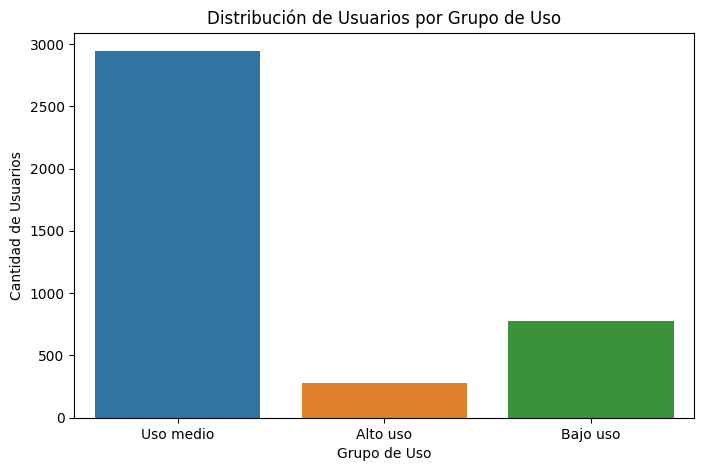

In [40]:

# Visualización de los segmentos por uso
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(
    data=user_profile,
    x='grupo_uso'
)
plt.title('Distribución de Usuarios por Grupo de Uso')
plt.xlabel('Grupo de Uso')
plt.ylabel('Cantidad de Usuarios')

plt.show()


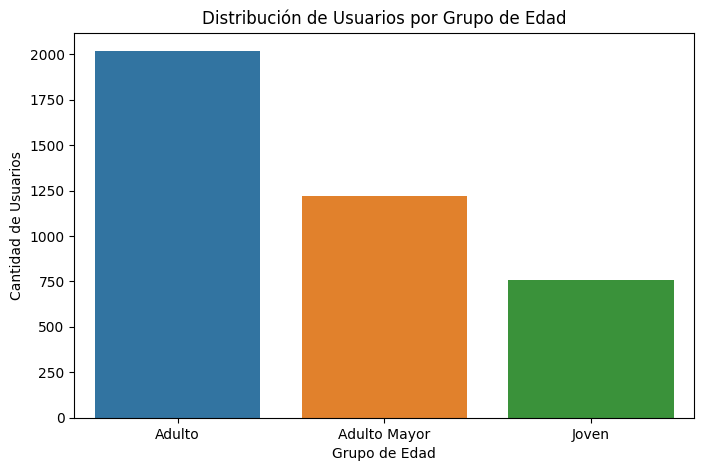

In [41]:
# Visualización de los segmentos por edad
plt.figure(figsize=(8, 5))
sns.countplot(
    data=user_profile,
    x='grupo_edad'
)

plt.title('Distribución de Usuarios por Grupo de Edad')
plt.xlabel('Grupo de Edad')
plt.ylabel('Cantidad de Usuarios')

plt.show()



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?


- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?  
- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?  
- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?


- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?

✍️ **Escribe aquí tu análisis ejecutivo:**

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- city: 11.7% nulos o “?” : información incompleta de ubicación.
- churn_date: 88% nulos : la mayoría de clientes siguen activos.
- usage: duration (55%) y length (44%) nulos, pero naturales según el tipo de uso (llamadas vs mensajes).
- Sentinels: edad -999 y fechas 2026 : corregidos.

🔍 **Segmentos por Edad**
- Jóvenes (18–32): uso moderado, sensibles al precio.
- Adultos (33–63): segmento más grande y estable; uso equilibrado.
- Mayores (64–79): menor volumen, pero uso constante de llamadas.


📊 **Segmentos por Nivel de Uso**
- Bajo uso: pocos mensajes/llamadas; clientes de bajo ARPU (Average Revenue Per User)
- Uso medio (mayoría): 4–7 mensajes, 3–7 llamadas, 20 min.
- Uso intensivo: outliers con muchos mensajes, llamadas y minutos, clientes de alto valor.

 ➡️ Esto sugiere que ... el negocio tiene una base amplia de usuarios de uso medio, con nichos pequeños de uso intensivo que pueden ser clave para ingresos y diseño de planes

 **Segmentos más valiosos**
- Heavy users (voz y mensajes): concentran consumo y extras.
- Clientes Premium: mayor pago mensual y uso más alto.
- Adultos de uso medio: base estable para retención y upgrades.
  
**Patrones de uso extremo**
- Mensajes altos (12–17), llamadas altas (10–14), minutos altos (60–150).
- Implican oportunidad de planes especializados y mayor ingreso por extras.


💡 **Recomendaciones**
- Crear planes para heavy users (voz, mensajes o mixtos).
- Ofrecer upgrades automáticos a usuarios que pagan muchos extras.
- Diseñar campañas segmentadas: jóvenes (datos), adultos (voz+datos), intensivos (planes ilimitados).
- Mantener reglas claras para sentinels y fechas futuras.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`